In [1]:
import os
os.environ['OMP_NUM_THREADS'] ='1'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
!pip install kneed
from kneed import KneeLocator

In [3]:
# 1. Load Data (Sesuai ketentuan: 2000 baris pertama)
df = pd.read_csv('RT_IOT2022.csv', nrows=2000)
df.to_csv('Dataset_2_RTIOT_2000.csv', index=False)

In [4]:
# 2. Preprocessing
# a. Data Cleaning: Menghapus baris yang duplikat
jumlah_awal = len(df)
df = df.drop_duplicates()
print(f"Data duplikat terhapus: {jumlah_awal - len(df)} baris")

# b. Data Cleaning: Menghapus baris yang memiliki missing values (NaN)
jumlah_sebelum_nan = len(df)
df = df.dropna()
print(f"Data missing values terhapus: {jumlah_sebelum_nan - len(df)} baris")

# c. Pemilihan Fitur: Membuang atribut non-numerik dan variabel target
kolom_buang = ['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'Attack_type']
df_numerik = df.drop(columns=[col for col in kolom_buang if col in df.columns])

# d. Transformasi Data: Z-Score Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numerik)

Data duplikat terhapus: 0 baris
Data missing values terhapus: 0 baris


In [5]:
# 3. Proses Clustering K-Means & Evaluasi
wcss = []
sil_scores = []
K_range = range(2, 11) # Mulai dari 2 karena Silhouette Score minimal butuh 2 cluster

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

Hasil deteksi otomatis K-Optimal dari Elbow Method: 5


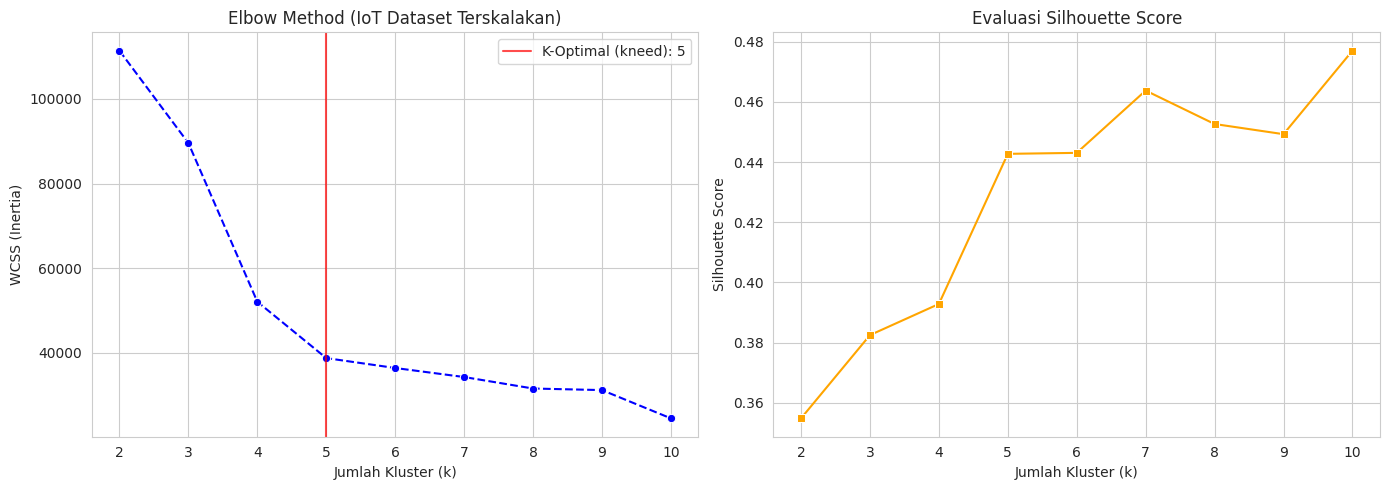

In [6]:
# 4. Mencari K-Optimal secara OTOMATIS (Menggunakan metode kneed dari dosen)
kl = KneeLocator(list(K_range), wcss, curve="convex", direction="decreasing")
k_optimal = kl.elbow

print(f"Hasil deteksi otomatis K-Optimal dari Elbow Method: {k_optimal}")

# Visualisasi Elbow & Silhouette dengan Seaborn (Gaya Dosen)
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Elbow Method
sns.lineplot(x=list(K_range), y=wcss, marker="o", linestyle="--", color="b", ax=ax[0])
if k_optimal:
    # Memberikan garis merah pada titik K optimal
    ax[0].axvline(k_optimal, color='r', linestyle='-', alpha=0.7, label=f'K-Optimal (kneed): {k_optimal}')
    ax[0].legend()
ax[0].set_xlabel("Jumlah Kluster (k)")
ax[0].set_ylabel("WCSS (Inertia)")
ax[0].set_title("Elbow Method (IoT Dataset Terskalakan)")

# Grafik 2: Silhouette Score
sns.lineplot(x=list(K_range), y=sil_scores, marker="s", linestyle="-", color="orange", ax=ax[1])
ax[1].set_xlabel("Jumlah Kluster (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Evaluasi Silhouette Score")
plt.tight_layout()
plt.show()

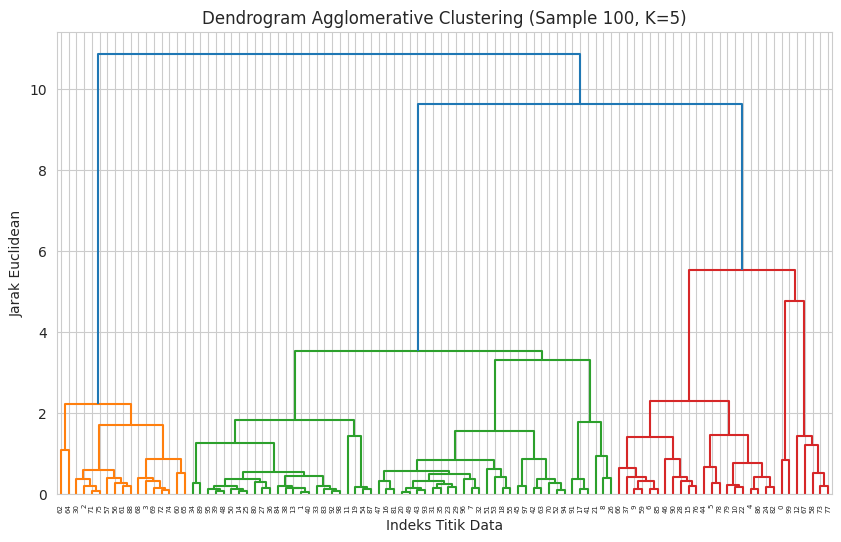

In [7]:
# 5. Agglomerative Clustering
# Menggunakan jumlah k_optimal dari deteksi kneed sebelumnya
k_final = k_optimal if k_optimal else 4

agglo = AgglomerativeClustering(n_clusters=k_final, metric='euclidean', linkage='ward')
df["Cluster_Agglo"] = agglo.fit_predict(X_scaled)

# Plot Dendrogram (Subset 100 sampel agar garis hierarkinya rapi dan bisa dibaca di report)
plt.figure(figsize=(10, 6))
plt.title(f"Dendrogram Agglomerative Clustering (Sample 100, K={k_final})")
sch.dendrogram(sch.linkage(X_scaled[:100], method='ward'))
plt.xlabel("Indeks Titik Data")
plt.ylabel("Jarak Euclidean")
plt.show()

In [8]:
# 6. Eksekusi Final K-Means & Mencetak Tabel Crosstab
# K-Means perlu di-run sekali lagi khusus untuk K=5 agar labelnya bisa disimpan
kmeans_final = KMeans(n_clusters=k_final, n_init='auto', random_state=42)
df["Cluster_KMeans"] = kmeans_final.fit_predict(X_scaled)

# Mencetak tabel tabulasi silang antara tebakan mesin dan label asli
tabel_crosstab = pd.crosstab(df["Cluster_KMeans"], df["Attack_type"])

print("\n=== TABEL DISTRIBUSI SERANGAN JARINGAN (CROSSTAB) ===")
print(tabel_crosstab)


=== TABEL DISTRIBUSI SERANGAN JARINGAN (CROSSTAB) ===
Attack_type     MQTT_Publish
Cluster_KMeans              
0                        849
1                       1031
2                         24
3                          6
4                         90
